# TCCT S92 - Blind Cardinality-Matched Relational Test

The S87D decoder and every TCCT mechanism remain frozen. Continue and Stop worlds are balanced and paired by topology, depth, and query position. Each valid pair must have exactly the same cardinality vector `{1,1,0}` while its full 27-dimensional feature vectors remain different.

This is a one-shot blind test with a new ten-branch grammar and depths 97/149. The protocol is hashed before world generation. Do not retune after either success or failure. Expected workload: 80 worlds.

Run **Kernel -> Restart Kernel and Run All Cells** once.


Dataset[{<|Stage -> S86, Name -> ExternalSixBranchBlind, CandidateFileLoaded -> True, 
 
>     CandidateHash -> a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     ExpectedCandidateHash -> 
 
>      a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     CandidateK -> 19, CandidatePolicyLength -> 26, 
 
>     OriginalFrozenModelChanged -> False, FrozenCandidateChanged -> False, 
 
>     CoreChanged -> False, PreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, CandidateFileLoaded, 
 
>      CandidateHash, ExpectedCandidateHash, CandidateK, CandidatePolicyLength, 
 
>      OriginalFrozenModelChanged, FrozenCandidateChanged, CoreChanged, PreflightPassed}\
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
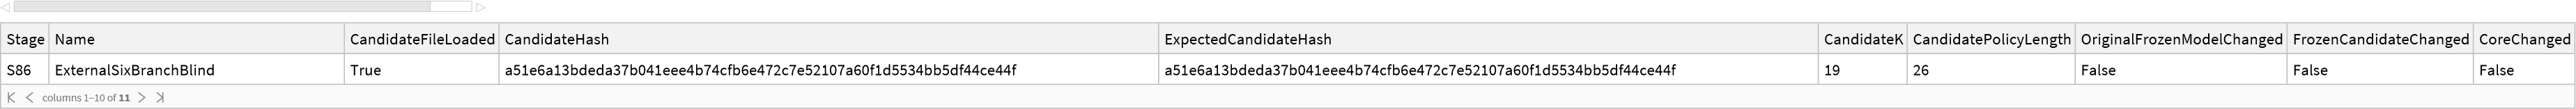

In [1544]:
ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8661d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];

ClearAll[ChainIn63, SharedMerge63, Case63];
ChainIn63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, inc, rm, add, new, n},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
inc=Cases[
e,
DirectedEdge[u_, v_ ] /; MemberQ[f, v]:>{u, v}
];
rm=DirectedEdge@@@inc;
add=Flatten[
Table[
n=mx+i;
{
DirectedEdge[inc[[i, 1]], n],
DirectedEdge[n, inc[[i, 2]]]
},
{i, Length[inc]}
],
1
];
new=Union[
Join[
Complement[e, rm],
add
]
];
{{new, x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
SharedMerge63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, ps, rm, g, i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>u
];
rm=(DirectedEdge[#, m]&)/@ps;
new=Complement[
new,
rm
];
g=mx+i;
new=Join[
new,
(DirectedEdge[#, g]&)/@ps,
{DirectedEdge[g, m]}
],
{i, Length[f]}
];
{{Union[new], x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
Case63[
g_String ,
d_Integer,
a_Integer,
t_String
]:=
Switch[
g,
"ChainIn",
ChainIn63[Case59[d, a, t]],
"SharedMerge",
SharedMerge63[Case59[d, a, t]]
];

ClearAll[ParallelIn71];
ParallelIn71[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, incs, rm,
add, next, g1, g2, i, j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>{u, v}
];
rm=DirectedEdge@@@incs;
add= {};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[incs[[j, 1]], g1],
DirectedEdge[g1, m],
DirectedEdge[incs[[j, 1]], g2],
DirectedEdge[g2, m]
}
],
{j, Length[incs]}
];
new=Join[
Complement[new, rm],
add
],
{i, Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
}, a}
];

(* In[410] *)
ClearAll[Case71];
Case71[
d_Integer,
a_Integer,
t_String
]:=
ParallelIn71[
Case59[d, a, t]
];

ClearAll[ParallelOut72,SharedParallelIn72,Case72B];
ParallelOut72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,outs,rm,
add,g1,g2,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
outs=Cases[
new,
DirectedEdge[u_,v_]/;u===m:>{u,v}
];
rm=DirectedEdge@@@outs;
add={};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[m,g1],
DirectedEdge[g1,outs[[j,2]]],
DirectedEdge[m,g2],
DirectedEdge[g2,outs[[j,2]]]
}
],
{j,Length[outs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

SharedParallelIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,ps,rm,
g1,g2,add,i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>u
];
rm=(DirectedEdge[#,m]&)/@ps;
g1=next;
g2=next+1;
next=next+2;
add=Join[
Flatten[
Table[
{
DirectedEdge[ps[[j]],g1],
DirectedEdge[ps[[j]],g2]
},
{j,Length[ps]}
],
1
],
{
DirectedEdge[g1,m],
DirectedEdge[g2,m]
}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

Case72B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"ParallelOut",
ParallelOut72[Case59[depth,answer,target]],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"SharedParallelIn",
SharedParallelIn72[Case59[depth,answer,target]],
_,
$Failed
];



ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];ClearAll[
LocalMediatorSources82,
FullSemanticPatch82,
LocalMediatorPatch82,
PatchSourceSet82,
ReferenceAction82
];

LocalMediatorSources82[c_List]:=Module[
{x=c[[1]],answer=c[[2]],m},
m=x[[6,answer]];
{m,m+1,m+2}
];

FullSemanticPatch82[
depth_Integer,
answer_Integer
]:=EdgePatch81[
Case59[depth,answer,"Continue"],
Case59[depth,answer,"Stop"]
];

LocalMediatorPatch82[
depth_Integer,
answer_Integer
]:=Module[
{factual,fullPatch,sources},
factual=Case59[depth,answer,"Continue"];
fullPatch=FullSemanticPatch82[depth,answer];
sources=LocalMediatorSources82[factual];
<|
"Remove"->Select[
fullPatch["Remove"],
MemberQ[sources,#[[1]]]&
],
"Add"->Select[
fullPatch["Add"],
MemberQ[sources,#[[1]]]&
]
|>
];

PatchSourceSet82[patch_Association]:=Union[
Map[First,patch["Remove"]],
Map[First,patch["Add"]]
];

ReferenceAction82[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],e,m,safe,u,dum,
correct,wrong,continueEdges,stopEdges
},
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dum=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dum]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],
"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],
"Stop",
True,
"Undefined"
]
];

interventionImplementationHash82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];expectedMinimalKernelDefinitionTextHash86=
"d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922";
expectedCanonicalizerHash86=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedStableFrozenArchitectureHash86=
"d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d";
expectedInterventionHash86=
"45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf";
expectedCandidateHash86=
"a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f";

candidateSnapshotPath86=
"E:/engine_wolf/TCCT_S83B_FrozenCandidate.wl";

If[
!FileExistsQ[candidateSnapshotPath86],
Print["S86 aborted: frozen S83B candidate file is missing."];
Abort[]
];

Get[candidateSnapshotPath86];

ClearAll[CoreDefinitionBundle86];
CoreDefinitionBundle86[]:={
DownValues[P59],DownValues[A59],DownValues[T59],DownValues[Case59],
OwnValues[rw60],DownValues[Pack60],DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],DownValues[EncodeRows75],
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],DownValues[Case79]
};

minimalKernelDefinitionTextHash86=Hash[
ToString[InputForm[CoreDefinitionBundle86[]]],
"SHA256","HexString"
];

stableFrozenArchitectureHash86=Hash[
{
Normal[frozen75D],
minimalKernelDefinitionTextHash86,
canonicalizerImplementationHash79B
},
"SHA256","HexString"
];

candidateHashLoaded86=If[
AssociationQ[frozenCandidate83B],
Hash[Normal[frozenCandidate83B],"SHA256","HexString"],
Missing["CandidateNotLoaded"]
];

preflightPassed86=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelDefinitionTextHash86,
expectedMinimalKernelDefinitionTextHash86
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash86
],
SameQ[
stableFrozenArchitectureHash86,
expectedStableFrozenArchitectureHash86
],
SameQ[interventionImplementationHash82,expectedInterventionHash86],
AssociationQ[frozenCandidate83B],
SameQ[candidateHashLoaded86,expectedCandidateHash86],
SameQ[frozenCandidate83B["BaseFrozenModelHash"],expectedFrozenModelHash79A],
SameQ[frozenCandidate83B["EncoderParams"],frozen75D["Params"]],
SameQ[frozenCandidate83B["Representation"],"KExactRole"],
SameQ[frozenCandidate83B["K"],19],
SameQ[Length[frozenCandidate83B["Policy"]],26],
SameQ[frozenCandidate83B["DevelopmentScore"],264],
TrueQ[frozenCandidate83B["ExactNodeRoleUsed"]],
TrueQ[frozenCandidate83B["FrozenBeforeS84"]]
];

preflight86=<|
"Stage"->"S86",
"Name"->"ExternalSixBranchBlind",
"CandidateFileLoaded"->FileExistsQ[candidateSnapshotPath86],
"CandidateHash"->candidateHashLoaded86,
"ExpectedCandidateHash"->expectedCandidateHash86,
"CandidateK"->If[AssociationQ[frozenCandidate83B],frozenCandidate83B["K"],Missing[]],
"CandidatePolicyLength"->If[
AssociationQ[frozenCandidate83B],Length[frozenCandidate83B["Policy"]],Missing[]
],
"OriginalFrozenModelChanged"->False,
"FrozenCandidateChanged"->False,
"CoreChanged"->False,
"PreflightPassed"->preflightPassed86
|>;

If[
!TrueQ[preflightPassed86],
Print[Dataset[{preflight86}]];
Print["S86 aborted: frozen architecture or S83B candidate mismatch."];
Abort[]
];

Dataset[{preflight86}]

Dataset[{<|Stage -> S92, Name -> CardinalityMatchedUniformActionBlind, 
 
>     CandidateFrozenBeforeProtocol -> True, 
 
>     DecoderCandidateHash -> 
 
>      703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     DecoderCandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     FeatureRuntimeFileHash -> 
 
>      7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee, 
 
>     K33CandidateHash -> 
 
>      2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, 
 
>     S90CheckpointLocked -> True, S91CheckpointLocked -> True, 
 
>     FeatureFamily -> QueriedGlobalMoments, FeatureDimension -> 27, BranchCount -> 10, 
 
>     Depths -> {97, 149}, TrainingRun -> False, CandidateSearchRun -> False, 
 
>     DecoderEditApplied -> False, RetuningApplied -> False, 
 
>     S92ResultAlreadyPresent -> False, PreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 19], 
 
>    1], <||>]
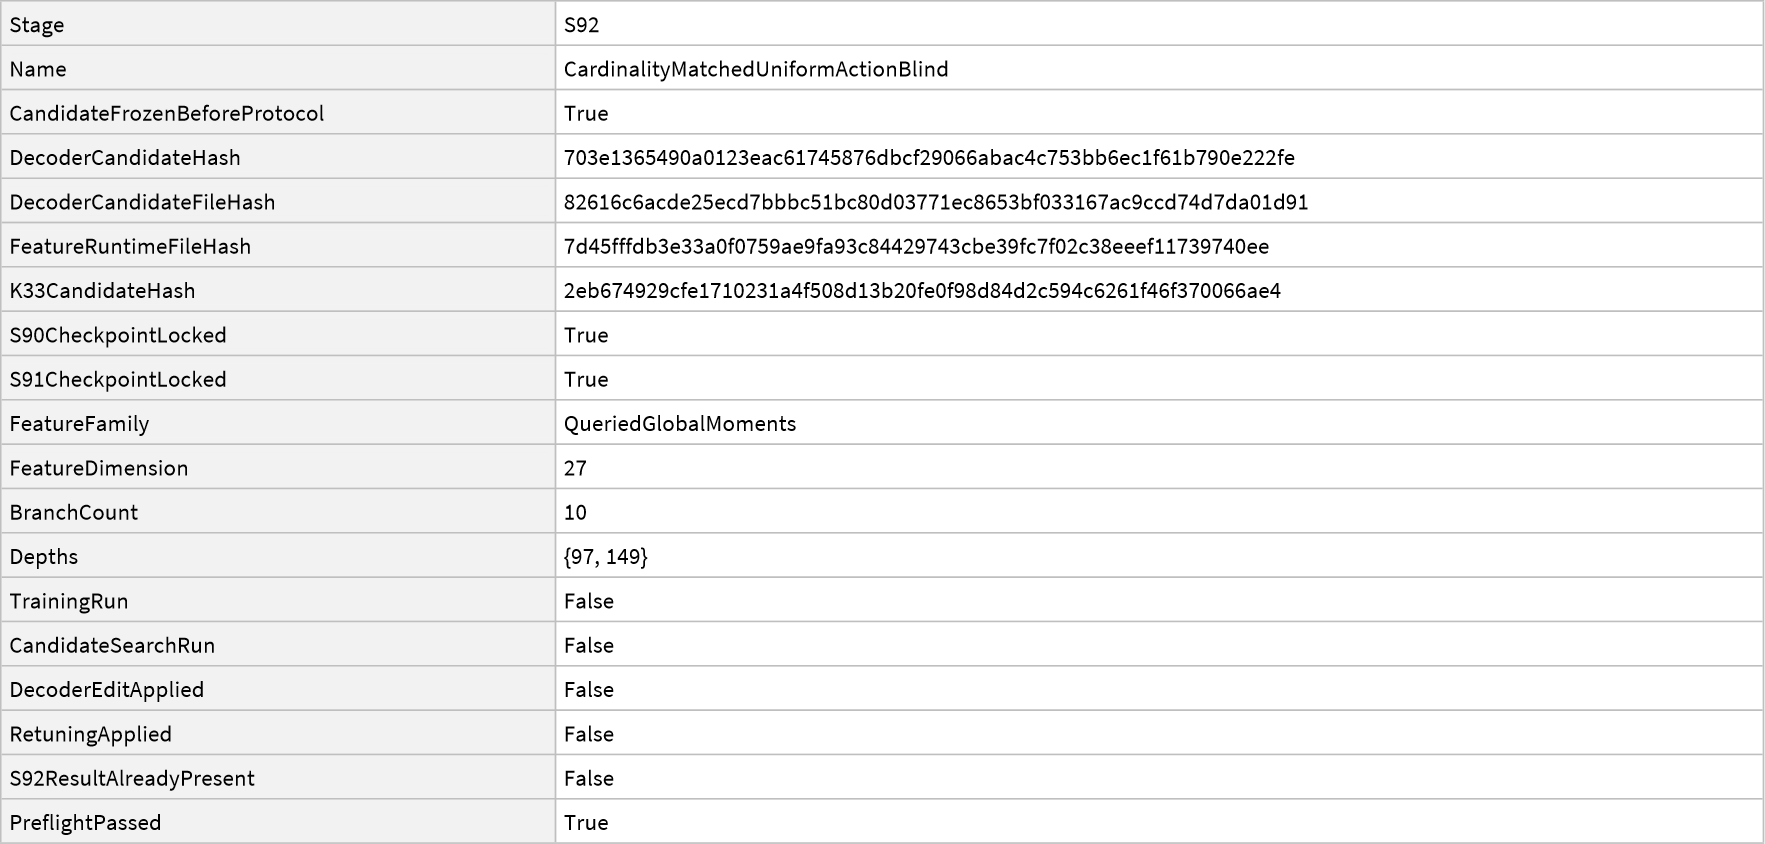

In [1632]:
expectedFrozenModelHash92=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedK33CandidateHash92=
"2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4";
expectedK33CandidateFileHash92=
"4a252b8977101d024b1b2feb00b4626ca28290c3982cdad199bc78ef7e0c98f1";
expectedDecoderCandidateHash92=
"703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe";
expectedDecoderCandidateFileHash92=
"82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91";
expectedClassifierBinaryHash92=
"2b8861c03c8169571061a85c12644c6e30a11e8f8f15f5c69c6761215f4752f1";
expectedFeatureRuntimeFileHash92=
"7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee";
expectedFreezeProtocolHash92=
"03d7a40eefdaec9d9fce599517d3663ba381d50218bfe4934580bd22ca31b86c";
expectedFreezeCertificateFileHash92=
"7c83717fc5bf50b1bde853401da8d0fc5931d6b1b23663d75777e1e45516fb8e";
expectedS90CheckpointFileHash92=
"0e8c9df9e63ea68d59226416de33243440ef4b84a007be0812b2970ed53deb30";
expectedS91CheckpointFileHash92=
"cf335bda73b8a26eacbf32d8d25dcad737a84d503a6f0849dbcd3afc3f1df8cd";

k33CandidatePath92="E:/engine_wolf/TCCT_S86E_K33FrozenCandidate.wl";
decoderRuntimePath92="E:/engine_wolf/TCCT_S87D_FrozenDecoderRuntime.wl";
decoderCandidatePath92="E:/engine_wolf/TCCT_S87D_FrozenWorldMultisetDecoder.wxf";
freezeCertificatePath92="E:/engine_wolf/TCCT_S87D_FreezeCertificate.json";
s90CheckpointPath92="E:/engine_wolf/TCCT_S90_BlindResultCertificate.json";
s91CheckpointPath92="E:/engine_wolf/TCCT_S91_BenchmarkCertificate.json";
s92ResultCertificatePath="E:/engine_wolf/TCCT_S92_BlindResultCertificate.json";

ClearAll[FileSHA256Hex92];
FileSHA256Hex92[path_String]:=If[FileExistsQ[path],
IntegerString[FileHash[path,"SHA256"],16,64],Missing["FileMissing",path]];
requiredFilesPresent92=And@@(FileExistsQ/@{
k33CandidatePath92,decoderRuntimePath92,decoderCandidatePath92,
freezeCertificatePath92,s90CheckpointPath92,s91CheckpointPath92});
If[!TrueQ[requiredFilesPresent92],
Print["S92 aborted: one or more locked input files are missing."];Abort[]];
If[FileExistsQ[s92ResultCertificatePath],
Print["S92 aborted: a prior S92 result certificate already exists."];
Print["Preserve it; do not overwrite or retune."];Abort[]];

k33CandidateFileHashBefore92=FileSHA256Hex92[k33CandidatePath92];
decoderRuntimeFileHashBefore92=FileSHA256Hex92[decoderRuntimePath92];
decoderCandidateFileHashBefore92=FileSHA256Hex92[decoderCandidatePath92];
freezeCertificateFileHashBefore92=FileSHA256Hex92[freezeCertificatePath92];
s90CheckpointFileHashBefore92=FileSHA256Hex92[s90CheckpointPath92];
s91CheckpointFileHashBefore92=FileSHA256Hex92[s91CheckpointPath92];

Clear[frozenCandidate86E];Get[k33CandidatePath92];
k33CandidateHashLoaded92=If[AssociationQ[frozenCandidate86E],
Hash[Normal[frozenCandidate86E],"SHA256","HexString"],Missing[]];
Get[decoderRuntimePath92];
frozenDecoderLoaded92=TCCTLoadFrozenDecoderS87D[decoderCandidatePath92];
frozenDecoderRaw92=If[AssociationQ[frozenDecoderLoaded92],
KeyDrop[frozenDecoderLoaded92,{"Classifier"}],$Failed];
decoderCandidateHashLoaded92=If[AssociationQ[frozenDecoderRaw92],
Lookup[frozenDecoderRaw92,"CandidateHash",Missing[]],Missing[]];
decoderPayloadHashLoaded92=If[AssociationQ[frozenDecoderRaw92],
Hash[Normal[KeyDrop[frozenDecoderRaw92,{"CandidateHash"}]],
"SHA256","HexString"],Missing[]];
freezeCertificate92=Quiet@Check[Import[freezeCertificatePath92,"RawJSON"],$Failed];
s90Checkpoint92=Quiet@Check[Import[s90CheckpointPath92,"RawJSON"],$Failed];
s91Checkpoint92=Quiet@Check[Import[s91CheckpointPath92,"RawJSON"],$Failed];

ClearAll[CoreDefinitionBundle92];
CoreDefinitionBundle92[]:=CoreDefinitionBundle86[];
modelHashBefore92=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashBefore92=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
decoderObjectHashBefore92=If[AssociationQ[frozenDecoderRaw92],
Hash[Normal[frozenDecoderRaw92],"SHA256","HexString"],Missing[]];
coreHashBefore92=Hash[CoreDefinitionBundle92[],"SHA256","HexString"];
canonicalizerHashBefore92=Hash[{
DownValues[FindPrivateDiamond79B],DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]},"SHA256","HexString"];
interventionHashBefore92=Hash[{
DownValues[LocalMediatorSources82],DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],DownValues[ReferenceAction82]},
"SHA256","HexString"];
topologyPrimitiveHashBefore92=Hash[{
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],
DownValues[HierarchicalDiamondIn80]},"SHA256","HexString"];
decoderRuntimeDefinitionHashBefore92=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"];

preflightPassed92=And[
TrueQ[preflightPassed86],SameQ[modelHashBefore92,expectedFrozenModelHash92],
AssociationQ[frozenCandidate86E],
SameQ[k33CandidateHashLoaded92,expectedK33CandidateHash92],
SameQ[k33CandidateFileHashBefore92,expectedK33CandidateFileHash92],
SameQ[frozenCandidate86E["K"],33],
SameQ[frozenCandidate86E["Representation"],"KExactRole"],
AssociationQ[frozenDecoderLoaded92],AssociationQ[frozenDecoderRaw92],
Head[frozenDecoderLoaded92["Classifier"]]===ClassifierFunction,
SameQ[decoderCandidateHashLoaded92,expectedDecoderCandidateHash92],
SameQ[decoderPayloadHashLoaded92,expectedDecoderCandidateHash92],
SameQ[decoderCandidateFileHashBefore92,expectedDecoderCandidateFileHash92],
SameQ[decoderRuntimeFileHashBefore92,expectedFeatureRuntimeFileHash92],
SameQ[frozenDecoderRaw92["ClassifierBinaryHash"],expectedClassifierBinaryHash92],
SameQ[frozenDecoderRaw92["FeatureRuntimeFileHash"],
FileHash[decoderRuntimePath92,"SHA256"]],
SameQ[frozenDecoderRaw92["ProtocolHash"],expectedFreezeProtocolHash92],
SameQ[frozenDecoderRaw92["FeatureFamily"],"QueriedGlobalMoments"],
SameQ[frozenDecoderRaw92["FeatureDimension"],27],
SameQ[frozenDecoderRaw92["K"],33],
SameQ[frozenDecoderRaw92["BaseFrozenModelHash"],expectedFrozenModelHash92],
SameQ[frozenDecoderRaw92["BaseK33CandidateHash"],expectedK33CandidateHash92],
TrueQ[frozenDecoderRaw92["FrozenBeforeS88"]],
TrueQ[frozenDecoderRaw92["S88DataReadBeforeFreeze"]===False],
AssociationQ[freezeCertificate92],
SameQ[freezeCertificateFileHashBefore92,expectedFreezeCertificateFileHash92],
TrueQ[freezeCertificate92["FreezeValidityPassed"]],
SameQ[freezeCertificate92["CandidateHash"],expectedDecoderCandidateHash92],
AssociationQ[s90Checkpoint92],
SameQ[s90CheckpointFileHashBefore92,expectedS90CheckpointFileHash92],
TrueQ[s90Checkpoint92["TestValidityPassed"]],TrueQ[s90Checkpoint92["BlindPerfect"]],
SameQ[s90Checkpoint92["Outcome"],"S90_BLIND_INTERVENTION_ALGEBRA_PASS"],
AssociationQ[s91Checkpoint92],
SameQ[s91CheckpointFileHashBefore92,expectedS91CheckpointFileHash92],
TrueQ[s91Checkpoint92["BenchmarkValidityPassed"]],
SameQ[s91Checkpoint92["FrozenCandidateHash"],expectedDecoderCandidateHash92],
SameQ[s91Checkpoint92["Outcome"],
"S91_VALID_POSTHOC_BASELINE_ABLATION_COMPLETE"],
!FileExistsQ[s92ResultCertificatePath]
];
preflight92=<|"Stage"->"S92","Name"->"CardinalityMatchedUniformActionBlind",
"CandidateFrozenBeforeProtocol"->True,
"DecoderCandidateHash"->decoderCandidateHashLoaded92,
"DecoderCandidateFileHash"->decoderCandidateFileHashBefore92,
"FeatureRuntimeFileHash"->decoderRuntimeFileHashBefore92,
"K33CandidateHash"->k33CandidateHashLoaded92,
"S90CheckpointLocked"->SameQ[s90CheckpointFileHashBefore92,
expectedS90CheckpointFileHash92],
"S91CheckpointLocked"->SameQ[s91CheckpointFileHashBefore92,
expectedS91CheckpointFileHash92],
"FeatureFamily"->If[AssociationQ[frozenDecoderRaw92],
frozenDecoderRaw92["FeatureFamily"],Missing[]],
"FeatureDimension"->If[AssociationQ[frozenDecoderRaw92],
frozenDecoderRaw92["FeatureDimension"],Missing[]],
"BranchCount"->10,"Depths"->{97,149},
"TrainingRun"->False,"CandidateSearchRun"->False,
"DecoderEditApplied"->False,"RetuningApplied"->False,
"S92ResultAlreadyPresent"->FileExistsQ[s92ResultCertificatePath],
"PreflightPassed"->preflightPassed92|>;
If[!TrueQ[preflightPassed92],Print[Dataset[{preflight92}]];
Print["S92 aborted: frozen inputs or checkpoint locks failed."];Abort[]];
Dataset[{preflight92}]

Dataset[{<|Stage -> S92, Name -> CardinalityMatchedUniformActionBlind, 
 
>     Candidate -> S87D-FrozenWorldMultisetDecoder, 
 
>     CandidateHash -> 703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     CandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     FeatureRuntimeFileHash -> 
 
>      7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee, 
 
>     K33CandidateHash -> 
 
>      2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, 
 
>     S90CheckpointFileHash -> 
 
>      0e8c9df9e63ea68d59226416de33243440ef4b84a007be0812b2970ed53deb30, 
 
>     S91CheckpointFileHash -> 
 
>      cf335bda73b8a26eacbf32d8d25dcad737a84d503a6f0849dbcd3afc3f1df8cd, 
 
>     BranchCount -> 10, Depths -> {97, 149}, 
 
>     Topologies -> {TripleSerialDiamondIn, HierarchicalTerminalDiamondIn}, 
 
>     TopologySpecHash -> 
 
>      bd903aeb069a3acbffbaf7013f1161cc97c8c922e6cde78368e4e7aeb83659de, 
 
>     ExpectedScenarios -> 4, ExpectedPairs -> 40, ExpectedWorlds -> 80, 
 
>     ExpectedContinueWorlds -> 40, ExpectedStopWorlds -> 40, 
 
>     ExternalGrammar -> IndependentTenBranchT92, 
 
>     ActionRegime -> UniformAllBranchesContinueVersusUniformAllBranchesStop, 
 
>     CardinalityConstraint -> EveryPairedWorldHasObservationDistinctPairCounts_1_1_0, 
 
>     Pairing -> SameTopologyDepthAnswerOppositeAction, 
 
>     FeatureFamily -> QueriedGlobalMoments, FeatureDimension -> 27, 
 
>     SuccessCriterion -> ValidHarnessExactCardinalityMatchAndAll80WorldsCorrect, 
 
>     CandidateFrozenBeforeProtocol -> True, S90CheckpointReadOnlyLock -> True, 
 
>     S91CheckpointReadOnlyLock -> True, TrainingRun -> False, 
 
>     CandidateSearchRun -> False, DecoderEditApplied -> False, 
 
>     RetuningApplied -> False, NoCaseEvaluatedBeforeProtocolHash -> True, 
 
>     ProtocolHash -> 4e7117970c3e5c4315fb4953364b632404566258a718c7807c8819ba3d30b6bb, 
 
>     TestDefinitionHash -> 
 
>      3f072d5e37942fd007dd5b6fa73319d47da23e41b61ca05486fccc040f2b4904|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 35], 
 
>    1], <||>]
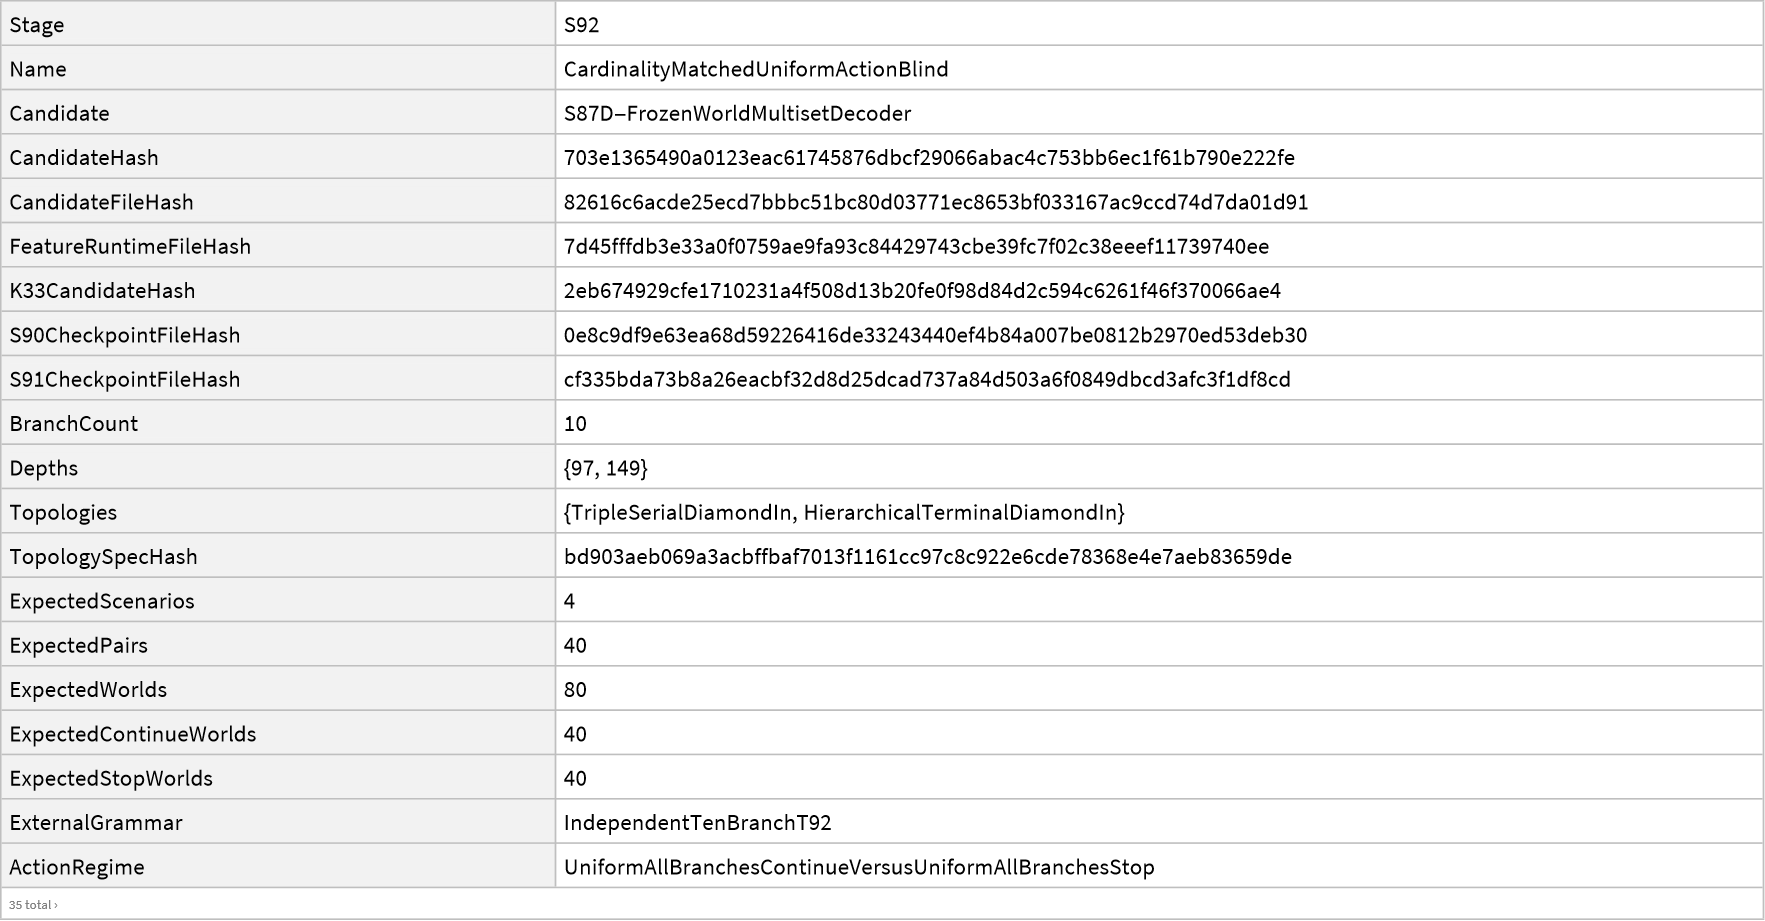

In [1689]:
ClearAll[T92,Case92,ReferenceAction92,NodeRole92,EncodePair92,
LegacyPredictTokens92,PredictFrozenDecoder92,TripleSerialDiamondIn92,
HierarchicalTerminalDiamondIn92,TopologyTransform92,ExpectedContractions92,
PrepareWorld92,PrepareScenario92,S92TestDefinitionBundle];

T92[depth_Integer,target_String,answer_Integer,seed_Integer,
branchCount_Integer]:=Module[
{bb,K,c,v,q,e,f={},ib,m,safe,u,dummy,r1,r2,wrong,main,perm,anc,i},
bb=1000000000 seed;K=bb+1;
c=Table[bb+100+i,{i,branchCount}];
v=Table[bb+200+i,{i,branchCount}];
q=Table[bb+300+i,{i,branchCount}];
e=Flatten[Table[{
DirectedEdge[K,c[[i]]],DirectedEdge[c[[i]],v[[i]]]},{i,branchCount}],1];
Do[
ib=bb+20000000 i;m=ib+1;safe=ib+2;u=ib+3;dummy=ib+4;
r1=ib+10;r2=ib+20;wrong=c[[1+Mod[i,branchCount]]];
main=Join[P59[q[[i]],r1,depth,ib+1000000],
P59[q[[i]],r2,depth,ib+2000000],
{DirectedEdge[r1,m],DirectedEdge[r2,m]},
P59[q[[i]],safe,depth+1,ib+3000000]];
perm=If[target==="Continue",
{DirectedEdge[m,c[[i]]],DirectedEdge[safe,dummy],DirectedEdge[u,wrong]},
{DirectedEdge[m,wrong],DirectedEdge[safe,c[[i]]],DirectedEdge[u,dummy]}];
anc=Join[A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]];
e=Join[e,main,perm,anc];AppendTo[f,m],{i,branchCount}];
{{Union[e],q,K,v,c,f},answer}
];
Case92[depth_Integer,answer_Integer,target_String]:=
T92[depth,target,answer,92000000+100 depth,10];

ReferenceAction92[c_List]:=Module[
{x=c[[1]],answer=c[[2]],branchCount,e,m,safe,u,dummy,correct,wrong,
continueEdges,stopEdges},
branchCount=Length[x[[6]]];e=x[[1]];m=x[[6,answer]];
safe=m+1;u=m+2;dummy=m+3;correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,branchCount]]];
continueEdges={DirectedEdge[m,correct],DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]};
stopEdges={DirectedEdge[m,wrong],DirectedEdge[safe,correct],
DirectedEdge[u,dummy]};
Which[And@@(MemberQ[e,#]&/@continueEdges),"Continue",
And@@(MemberQ[e,#]&/@stopEdges),"Stop",True,"Undefined"]
];

NodeRole92[originalNode_,case_List,answer_Integer]:=Module[
{x,branchCount,m,correct,wrong,dummy,querySources,queryBranch,role},
x=case[[1]];branchCount=Length[x[[6]]];m=x[[6,answer]];
correct=x[[5,answer]];wrong=x[[5,1+Mod[answer,branchCount]]];dummy=m+3;
querySources={m,m+1,m+2};queryBranch=Union[querySources,{correct,wrong,dummy}];
role=Which[SameQ[originalNode,m],"QueriedDecision",
MemberQ[querySources,originalNode],"QueriedMediatorSource",
SameQ[originalNode,correct],"QueriedCorrectDestination",
SameQ[originalNode,wrong],"QueriedWrongDestination",
SameQ[originalNode,dummy],"QueriedDummyDestination",
MemberQ[x[[6]],originalNode],"OtherDecision",
MemberQ[x[[5]],originalNode],"OtherAnswerDestination",True,"OtherReject"];
<|"Role"->role,"QueryBranchRelated"->MemberQ[queryBranch,originalNode]|>
];

EncodePair92[pair_List]:=Module[{encoded},
encoded=First@EncodeRows75[{<|"Grammar"->"S92BlindObservation",
"Depth"->0,"Answer"->0,"Target"->"Unlabeled","StatePairs"->{pair}|>},
frozenCandidate86E["EncoderParams"],frozenCandidate86E["K"]];
First[encoded["Codes"]]];
LegacyPredictTokens92[tokens_List]:=If[AnyTrue[tokens,
MemberQ[frozenCandidate86E["Policy"],#]&],"Continue","Stop"];
PredictFrozenDecoder92[observations_List]:=Module[{prediction},
prediction=TCCTPredictWorldS87D[<|"Observations"->observations|>,
frozenDecoderLoaded92];
If[MemberQ[{"Continue","Stop"},prediction],prediction,$Failed]];

TripleSerialDiamondIn92[c_List]:=DiamondIn72[DoubleDiamondIn79[c]];
HierarchicalTerminalDiamondIn92[c_List]:=
DiamondIn72[HierarchicalDiamondIn80[c]];
TopologyTransform92[topology_String,c_List]:=Switch[topology,
"TripleSerialDiamondIn",TripleSerialDiamondIn92[c],
"HierarchicalTerminalDiamondIn",HierarchicalTerminalDiamondIn92[c],_,$Failed];
ExpectedContractions92[topology_String,baseCase_List]:=Switch[topology,
"TripleSerialDiamondIn",3 DecisionIncomingEdgeCount79B[baseCase],
"HierarchicalTerminalDiamondIn",4 DecisionIncomingEdgeCount79B[baseCase],
_,Missing["UnknownTopology"]];

PrepareWorld92[topology_String,depth_Integer,target_String,
answer_Integer]:=Module[
{baseCase,topologyCase,canonicalization,canonicalCase,expectedContractions,
traceSeconds,trace,levels,pack,vertexList,packedNodes,observations,
originalNode,pair,roleInfo,rawTokens,tokens,featureVector,
legacyPrediction,prediction},
baseCase=Case92[depth,answer,target];
topologyCase=TopologyTransform92[topology,baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
expectedContractions=ExpectedContractions92[topology,baseCase];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[Length[trace["Rejects"]]===0,{},
DeleteDuplicates[trace["Rejects"][[All,2]]]];
observations=Map[Function[packedNode,
originalNode=vertexList[[packedNode]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
roleInfo=NodeRole92[originalNode,canonicalCase,answer];
<|"Role"->roleInfo["Role"],
"QueryBranchRelated"->roleInfo["QueryBranchRelated"],
"Code"->EncodePair92[pair]|>],packedNodes];
rawTokens=({#1["Role"],#1["Code"]}&)/@observations;
tokens=DeleteDuplicates[rawTokens];
featureVector=TCCTWorldVectorS87D[<|"Observations"->observations|>];
legacyPrediction=LegacyPredictTokens92[tokens];
prediction=PredictFrozenDecoder92[observations];
<|"Topology"->topology,"Depth"->depth,"GraphCondition"->
"Uniform"<>target,"Answer"->answer,"Target"->target,
"ReferenceAction"->ReferenceAction92[canonicalCase],"BranchCount"->10,
"Prediction"->prediction,"LegacyPrediction"->legacyPrediction,
"FeatureVector"->featureVector,"Cardinality"->featureVector[[{1,2,18}]],
"Correct"->SameQ[prediction,target],
"TopologyGraphHash"->Hash[topologyCase[[1,1]],"SHA256","HexString"],
"CanonicalGraphHash"->Hash[canonicalCase[[1,1]],"SHA256","HexString"],
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"Contractions"->canonicalization["Contractions"],
"ExpectedContractions"->expectedContractions,
"ContractionCountCorrect"->SameQ[canonicalization["Contractions"],
expectedContractions],
"ProtectedNodesPreserved"->canonicalization["ProtectedNodesPreserved"],
"StateObservationCount"->Length[observations],
"RawTokenCount"->Length[rawTokens],"TokenCount"->Length[tokens],
"DuplicateTokensRemoved"->Length[rawTokens]-Length[tokens],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],"Rounds"->trace["Rounds"],
"TraceSeconds"->traceSeconds|>
];

PrepareScenario92[topology_String,depth_Integer]:=Module[
{continueWorlds,stopWorlds,worldPairs,continueHashes,stopHashes},
continueWorlds=Table[PrepareWorld92[topology,depth,"Continue",answer],
{answer,Range[10]}];
stopWorlds=Table[PrepareWorld92[topology,depth,"Stop",answer],
{answer,Range[10]}];
worldPairs=MapThread[Function[{continue,stop},<|
"Answer"->continue["Answer"],
"SameAnswer"->SameQ[continue["Answer"],stop["Answer"]],
"CardinalityExactlyMatched"->SameQ[continue["Cardinality"],
stop["Cardinality"],{1,1,0}],
"FullFeatureVectorsDifferent"->UnsameQ[continue["FeatureVector"],
stop["FeatureVector"]],
"ReferenceRelationCorrect"->And[
SameQ[continue["ReferenceAction"],"Continue"],
SameQ[stop["ReferenceAction"],"Stop"]],
"PredictionRelationCorrect"->And[
SameQ[continue["Prediction"],"Continue"],
SameQ[stop["Prediction"],"Stop"]],
"PairCorrect"->And[TrueQ[continue["Correct"]],TrueQ[stop["Correct"]]]|>],
{continueWorlds,stopWorlds}];
continueHashes=Lookup[continueWorlds,"TopologyGraphHash"];
stopHashes=Lookup[stopWorlds,"TopologyGraphHash"];
<|"Topology"->topology,"Depth"->depth,
"ContinueSameGraphAcrossQueries"->SameQ@@continueHashes,
"StopSameGraphAcrossQueries"->SameQ@@stopHashes,
"OppositeActionsUseDifferentGraphs"->UnsameQ[First[continueHashes],
First[stopHashes]],
"AllCardinalitiesExactlyMatched"->And@@Lookup[worldPairs,
"CardinalityExactlyMatched"],
"AllFullFeatureVectorsDifferent"->And@@Lookup[worldPairs,
"FullFeatureVectorsDifferent"],
"ReferenceRelationsCorrect"->And@@Lookup[worldPairs,
"ReferenceRelationCorrect"],
"PredictionRelationsCorrect"->And@@Lookup[worldPairs,
"PredictionRelationCorrect"],
"AllTwentyWorldsCorrect"->And@@Join[Lookup[continueWorlds,"Correct"],
Lookup[stopWorlds,"Correct"]],"WorldPairs"->worldPairs,
"ContinueWorlds"->continueWorlds,"StopWorlds"->stopWorlds|>
];

S92TestDefinitionBundle[]:={DownValues[T92],DownValues[Case92],
DownValues[ReferenceAction92],DownValues[NodeRole92],DownValues[EncodePair92],
DownValues[LegacyPredictTokens92],DownValues[PredictFrozenDecoder92],
DownValues[TripleSerialDiamondIn92],DownValues[HierarchicalTerminalDiamondIn92],
DownValues[TopologyTransform92],DownValues[ExpectedContractions92],
DownValues[PrepareWorld92],DownValues[PrepareScenario92]};

blindBranchCount92=10;blindDepths92={97,149};
blindTopologies92={"TripleSerialDiamondIn","HierarchicalTerminalDiamondIn"};
topologySpec92=<|"TripleSerialDiamondIn"->
"DiamondIn72AfterDoubleDiamondIn79","HierarchicalTerminalDiamondIn"->
"DiamondIn72AfterHierarchicalDiamondIn80"|>;
topologySpecHash92=Hash[Normal[topologySpec92],"SHA256","HexString"];
testDefinitionHashBefore92=Hash[S92TestDefinitionBundle[],"SHA256","HexString"];
noCasesBeforeProtocolHash92=And[!ValueQ[blindScenarios92],
!ValueQ[blindWorlds92]];
protocol92=<|"Stage"->"S92","Name"->
"CardinalityMatchedUniformActionBlind",
"Candidate"->"S87D-FrozenWorldMultisetDecoder",
"CandidateHash"->decoderCandidateHashLoaded92,
"CandidateFileHash"->decoderCandidateFileHashBefore92,
"FeatureRuntimeFileHash"->decoderRuntimeFileHashBefore92,
"K33CandidateHash"->k33CandidateHashLoaded92,
"S90CheckpointFileHash"->s90CheckpointFileHashBefore92,
"S91CheckpointFileHash"->s91CheckpointFileHashBefore92,
"BranchCount"->blindBranchCount92,"Depths"->blindDepths92,
"Topologies"->blindTopologies92,"TopologySpecHash"->topologySpecHash92,
"ExpectedScenarios"->4,"ExpectedPairs"->40,"ExpectedWorlds"->80,
"ExpectedContinueWorlds"->40,"ExpectedStopWorlds"->40,
"ExternalGrammar"->"IndependentTenBranchT92",
"ActionRegime"->"UniformAllBranchesContinueVersusUniformAllBranchesStop",
"CardinalityConstraint"->
"EveryPairedWorldHasObservationDistinctPairCounts_1_1_0",
"Pairing"->"SameTopologyDepthAnswerOppositeAction",
"FeatureFamily"->"QueriedGlobalMoments","FeatureDimension"->27,
"SuccessCriterion"->
"ValidHarnessExactCardinalityMatchAndAll80WorldsCorrect",
"CandidateFrozenBeforeProtocol"->True,
"S90CheckpointReadOnlyLock"->True,"S91CheckpointReadOnlyLock"->True,
"TrainingRun"->False,"CandidateSearchRun"->False,
"DecoderEditApplied"->False,"RetuningApplied"->False,
"NoCaseEvaluatedBeforeProtocolHash"->noCasesBeforeProtocolHash92|>;
protocolHash92=Hash[Normal[protocol92],"SHA256","HexString"];
Dataset[{Join[protocol92,<|"ProtocolHash"->protocolHash92,
"TestDefinitionHash"->testDefinitionHashBefore92|>]}]

Dataset[{<|Scenarios -> 4, Pairs -> 40, Worlds -> 80, ContinueWorlds -> 40, 
 
>     StopWorlds -> 40, ContinueCorrect -> 40, StopCorrect -> 0, WorldCorrect -> 40, 
 
>     PairCorrect -> 0, CardinalityPairsMatched -> 40, 
 
>     FullFeatureVectorPairsDifferent -> 40, ReferenceRelationsCorrect -> 40, 
 
>     PredictionRelationsCorrect -> 0, ReferenceActionsCorrect -> 80, 
 
>     CardinalityOneOneZero -> 80, CanonicalCaseExactlyBase -> 80, 
 
>     ContractionCountCorrect -> 80, ProtectedNodesPreserved -> 80, 
 
>     ValidFeatureVectors -> 80, PredictionFailures -> 0, TerminatedNaturally -> 80, 
 
>     HitSafetyCap -> 0, TenBranchWorlds -> 80, ScenarioCardinalityMatched -> 4, 
 
>     ScenarioFullVectorsDifferent -> 4, ScenarioReferenceRelationsCorrect -> 4, 
 
>     ScenarioPerfect -> 0, TotalTraceSeconds -> 248.921|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`Atom[Real], 
 
>     28], 1], <||>]
Dataset[{<|Topology -> TripleSerialDiamondIn, Worlds -> 40, Correct -> 20, 
 
>     ContinueCorrect -> 20, StopCorrect -> 0|>, 
 
>    <|Topology -> HierarchicalTerminalDiamondIn, Worlds -> 40, Correct -> 20, 
 
>     ContinueCorrect -> 20, StopCorrect -> 0|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Topology, Worlds, Correct, ContinueCorrect, 
 
>      StopCorrect}, {TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 2]
 
>    , <||>]
Dataset[{<|Depth -> 97, Worlds -> 40, Correct -> 20, ContinueCorrect -> 20, 
 
>     StopCorrect -> 0|>, <|Depth -> 149, Worlds -> 40, Correct -> 20, 
 
>     ContinueCorrect -> 20, StopCorrect -> 0|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Worlds, Correct, ContinueCorrect, 
 
>      StopCorrect}, {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 2]
 
>    , <||>]
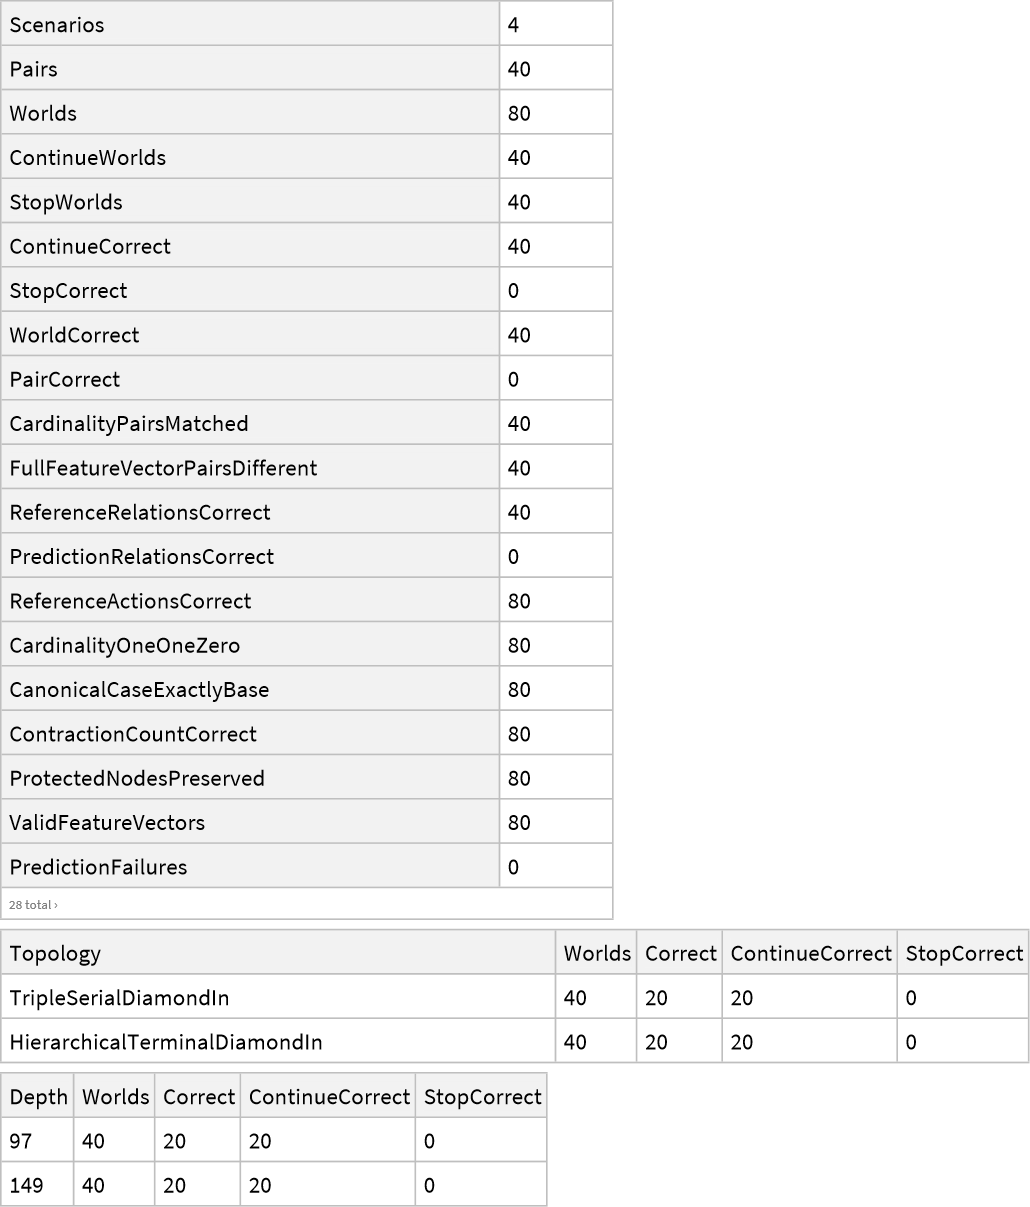

In [1717]:
blindScenarios92=Flatten[Table[PrepareScenario92[topology,depth],
{topology,blindTopologies92},{depth,blindDepths92}],1];
continueWorlds92=Flatten[Lookup[blindScenarios92,"ContinueWorlds"],1];
stopWorlds92=Flatten[Lookup[blindScenarios92,"StopWorlds"],1];
blindWorlds92=Join[continueWorlds92,stopWorlds92];
blindPairs92=Flatten[Lookup[blindScenarios92,"WorldPairs"],1];

summary92=<|"Scenarios"->Length[blindScenarios92],
"Pairs"->Length[blindPairs92],"Worlds"->Length[blindWorlds92],
"ContinueWorlds"->Length[continueWorlds92],"StopWorlds"->Length[stopWorlds92],
"ContinueCorrect"->Count[continueWorlds92,w_/;TrueQ[w["Correct"]]],
"StopCorrect"->Count[stopWorlds92,w_/;TrueQ[w["Correct"]]],
"WorldCorrect"->Count[blindWorlds92,w_/;TrueQ[w["Correct"]]],
"PairCorrect"->Count[blindPairs92,p_/;TrueQ[p["PairCorrect"]]],
"CardinalityPairsMatched"->Count[blindPairs92,p_/;
TrueQ[p["CardinalityExactlyMatched"]]],
"FullFeatureVectorPairsDifferent"->Count[blindPairs92,p_/;
TrueQ[p["FullFeatureVectorsDifferent"]]],
"ReferenceRelationsCorrect"->Count[blindPairs92,p_/;
TrueQ[p["ReferenceRelationCorrect"]]],
"PredictionRelationsCorrect"->Count[blindPairs92,p_/;
TrueQ[p["PredictionRelationCorrect"]]],
"ReferenceActionsCorrect"->Count[blindWorlds92,w_/;
SameQ[w["ReferenceAction"],w["Target"]]],
"CardinalityOneOneZero"->Count[blindWorlds92,w_/;
SameQ[w["Cardinality"],{1,1,0}]],
"CanonicalCaseExactlyBase"->Count[blindWorlds92,w_/;
TrueQ[w["CanonicalCaseExactlyBase"]]],
"ContractionCountCorrect"->Count[blindWorlds92,w_/;
TrueQ[w["ContractionCountCorrect"]]],
"ProtectedNodesPreserved"->Count[blindWorlds92,w_/;
TrueQ[w["ProtectedNodesPreserved"]]],
"ValidFeatureVectors"->Count[blindWorlds92,w_/;
VectorQ[w["FeatureVector"],IntegerQ]&&Length[w["FeatureVector"]]===27],
"PredictionFailures"->Count[blindWorlds92,w_/;SameQ[w["Prediction"],$Failed]],
"TerminatedNaturally"->Count[blindWorlds92,w_/;
TrueQ[w["TerminatedNaturally"]]],
"HitSafetyCap"->Count[blindWorlds92,w_/;TrueQ[w["HitSafetyCap"]]],
"TenBranchWorlds"->Count[blindWorlds92,w_/;SameQ[w["BranchCount"],10]],
"ScenarioCardinalityMatched"->Count[blindScenarios92,s_/;
TrueQ[s["AllCardinalitiesExactlyMatched"]]],
"ScenarioFullVectorsDifferent"->Count[blindScenarios92,s_/;
TrueQ[s["AllFullFeatureVectorsDifferent"]]],
"ScenarioReferenceRelationsCorrect"->Count[blindScenarios92,s_/;
TrueQ[s["ReferenceRelationsCorrect"]]],
"ScenarioPerfect"->Count[blindScenarios92,s_/;TrueQ[s["AllTwentyWorldsCorrect"]]],
"TotalTraceSeconds"->Total@Lookup[blindWorlds92,"TraceSeconds"]|>;

byTopology92=Map[Function[topology,Module[{worlds},
worlds=Select[blindWorlds92,SameQ[#1["Topology"],topology]&];
<|"Topology"->topology,"Worlds"->Length[worlds],
"Correct"->Count[worlds,w_/;TrueQ[w["Correct"]]],
"ContinueCorrect"->Count[worlds,w_/;
SameQ[w["Target"],"Continue"]&&TrueQ[w["Correct"]]],
"StopCorrect"->Count[worlds,w_/;
SameQ[w["Target"],"Stop"]&&TrueQ[w["Correct"]]]|>]],blindTopologies92];
byDepth92=Map[Function[depth,Module[{worlds},
worlds=Select[blindWorlds92,SameQ[#1["Depth"],depth]&];
<|"Depth"->depth,"Worlds"->Length[worlds],
"Correct"->Count[worlds,w_/;TrueQ[w["Correct"]]],
"ContinueCorrect"->Count[worlds,w_/;
SameQ[w["Target"],"Continue"]&&TrueQ[w["Correct"]]],
"StopCorrect"->Count[worlds,w_/;
SameQ[w["Target"],"Stop"]&&TrueQ[w["Correct"]]]|>]],blindDepths92];
Column[{Dataset[{summary92}],Dataset[byTopology92],Dataset[byDepth92]}]

Dataset[{<|Stage -> S92, Name -> CardinalityMatchedUniformActionBlind, 
 
>     CandidateHash -> 703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     CandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     S90CheckpointFileHash -> 
 
>      0e8c9df9e63ea68d59226416de33243440ef4b84a007be0812b2970ed53deb30, 
 
>     S91CheckpointFileHash -> 
 
>      cf335bda73b8a26eacbf32d8d25dcad737a84d503a6f0849dbcd3afc3f1df8cd, 
 
>     ProtocolHash -> 4e7117970c3e5c4315fb4953364b632404566258a718c7807c8819ba3d30b6bb, 
 
>     TestDefinitionHash -> 
 
>      3f072d5e37942fd007dd5b6fa73319d47da23e41b61ca05486fccc040f2b4904, 
 
>     BranchCount -> 10, Depths -> {97, 149}, 
 
>     Topologies -> {TripleSerialDiamondIn, HierarchicalTerminalDiamondIn}, 
 
>     Scenarios -> 4, Pairs -> 40, Worlds -> 80, ContinueCorrect -> 40, 
 
>     StopCorrect -> 0, WorldCorrect -> 40, Accuracy -> 0.5, BalancedAccuracy -> 0.5, 
 
>     PairCorrect -> 0, CardinalityPairsMatched -> 40, CardinalityOneOneZero -> 80, 
 
>     FullFeatureVectorPairsDifferent -> 40, CardinalityValidityPassed -> True, 
 
>     OriginalFrozenModelChanged -> False, OriginalK33CandidateChanged -> False, 
 
>     FrozenDecoderChanged -> False, CoreChanged -> False, 
 
>     CanonicalizerChanged -> False, InterventionCoreChanged -> False, 
 
>     TopologyPrimitivesChanged -> False, FeatureRuntimeChanged -> False, 
 
>     TestDefinitionChangedDuringRun -> False, ProtocolChangedDuringRun -> False, 
 
>     DeduplicationMechanismChanged -> False, UndirectedFreezeMechanismChanged -> False, 
 
>     S90CheckpointChanged -> False, S91CheckpointChanged -> False, 
 
>     TestValidityPassed -> True, BlindPerfect -> False, 
 
>     CandidateFrozenBeforeS92 -> True, BlindProtocolHashedBeforeCases -> True, 
 
>     S87DDecoderUsed -> True, S91CheckpointLocked -> True, TrainingRun -> False, 
 
>     CandidateSearchRun -> False, DecoderEditApplied -> False, 
 
>     RetuningApplied -> False, HistoricalBlindTestsRerun -> False, 
 
>     S92IsBlindCardinalityMatchedRelationalTest -> True, 
 
>     MayClaimCardinalityShortcutExcluded -> True, 
 
>     MayClaimBlindRelationalTransferBeyondCardinality -> False, 
 
>     MayClaimGeneralCounterfactualReasoning -> False, MayClaimCausalDiscovery -> False, 
 
>     TotalTraceSeconds -> 248.921, 
 
>     BlindResultHash -> 
 
>      a715ad1366f300a3e149c9f1df83c8e81744a7583678482900ed8736e4fc2273, 
 
>     Outcome -> S92_VALID_BLIND_FAILURE_DO_NOT_RETUNE, 
 
>     SuggestedNextStage -> S92A_FAILURE_AUDIT_THEN_RETRAINED_RELATIONAL_DECODER|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 58], 
 
>    1], <||>]
Dataset[{<|CertificateExported -> True, 
 
>     CertificatePath -> E:/engine_wolf/TCCT_S92_BlindResultCertificate.json, 
 
>     CertificateFileHash -> 
 
>      22cec6972285fe127e66d740bfdbbf27fbabaa097cb24cc0bbc7196da004a40b|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{CertificateExported, CertificatePath, 
 
>      CertificateFileHash}, {TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[String]}], 1], <||>]
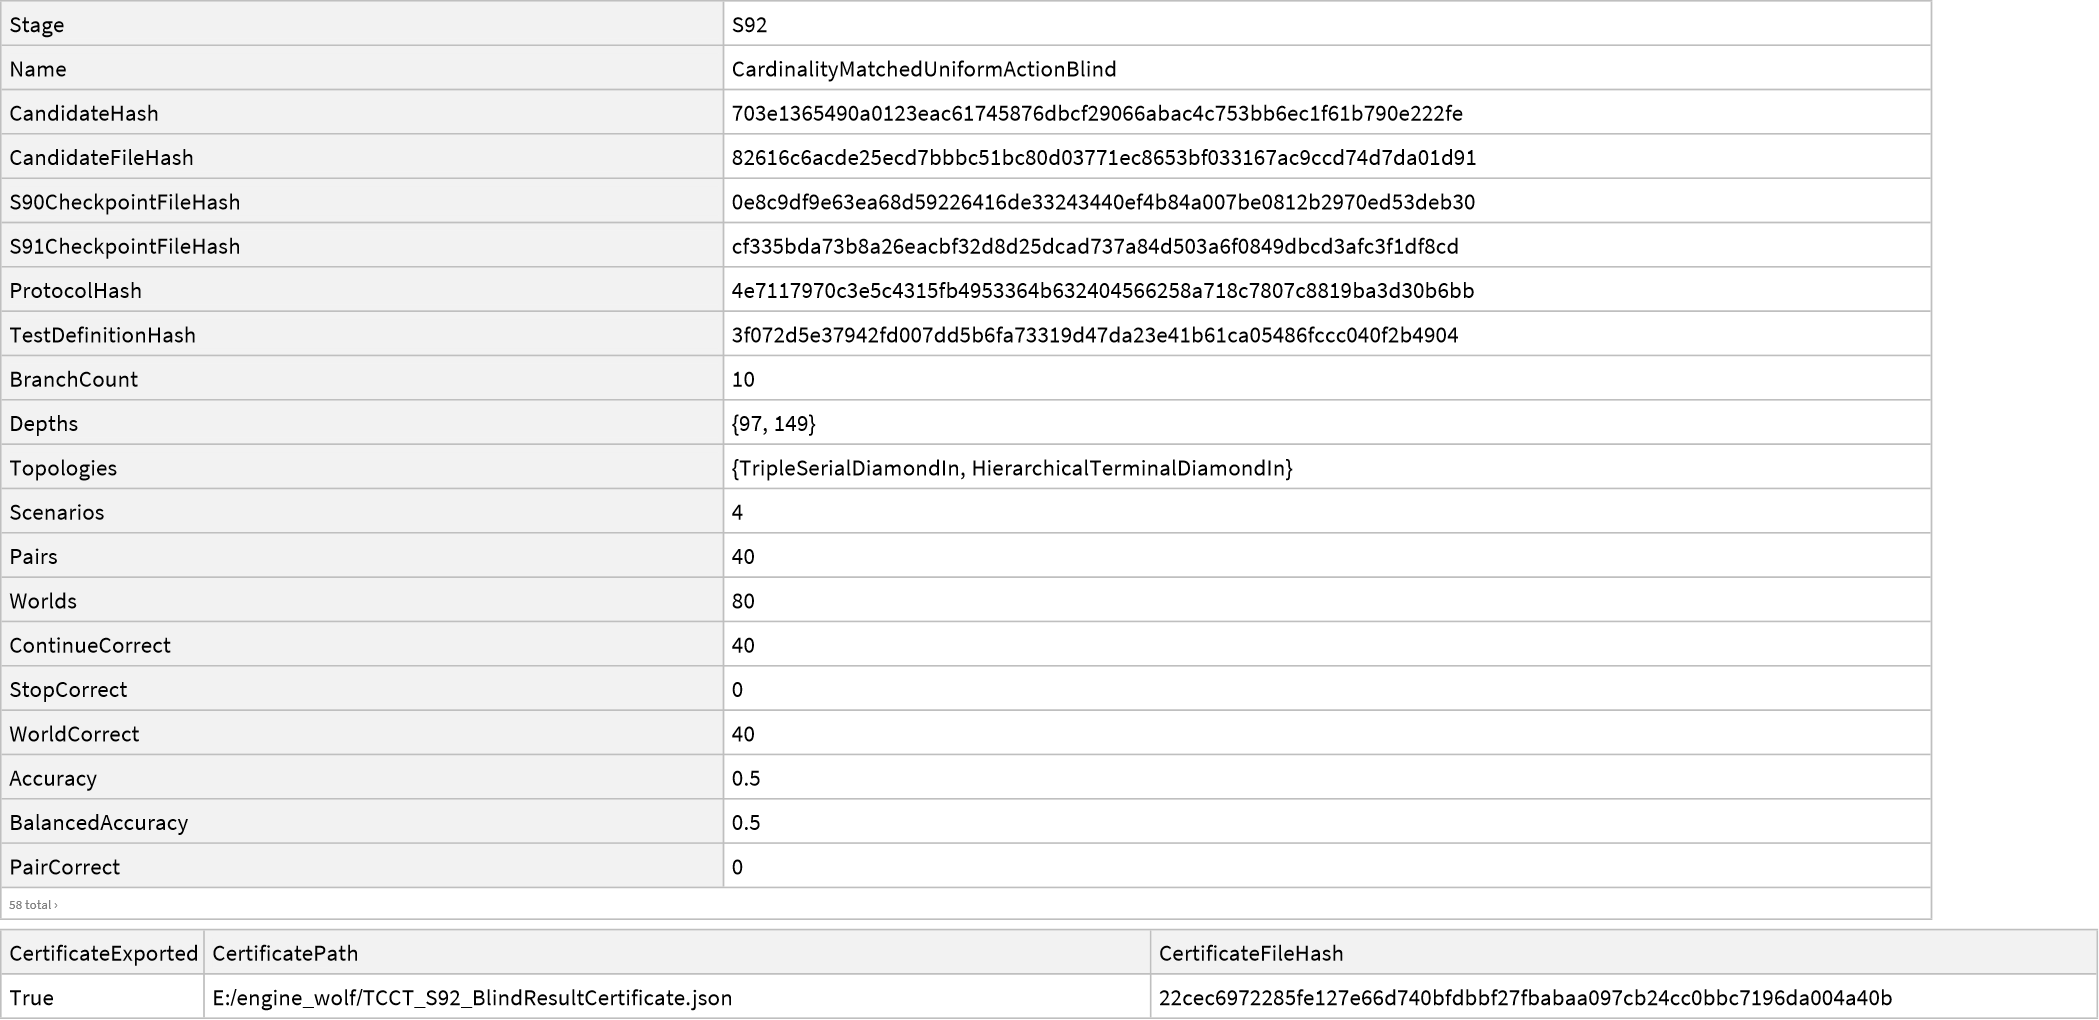

In [1726]:
modelHashAfter92=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashAfter92=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
decoderRawAfter92=KeyDrop[frozenDecoderLoaded92,{"Classifier"}];
decoderObjectHashAfter92=Hash[Normal[decoderRawAfter92],"SHA256","HexString"];
coreHashAfter92=Hash[CoreDefinitionBundle92[],"SHA256","HexString"];
canonicalizerHashAfter92=Hash[{DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],DownValues[CanonicalCase79B]},
"SHA256","HexString"];
interventionHashAfter92=Hash[{DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]},"SHA256","HexString"];
topologyPrimitiveHashAfter92=Hash[{DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"];
decoderRuntimeDefinitionHashAfter92=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"];
testDefinitionHashAfter92=Hash[S92TestDefinitionBundle[],"SHA256","HexString"];
protocolHashAfter92=Hash[Normal[protocol92],"SHA256","HexString"];
k33CandidateFileHashAfter92=FileSHA256Hex92[k33CandidatePath92];
decoderRuntimeFileHashAfter92=FileSHA256Hex92[decoderRuntimePath92];
decoderCandidateFileHashAfter92=FileSHA256Hex92[decoderCandidatePath92];
freezeCertificateFileHashAfter92=FileSHA256Hex92[freezeCertificatePath92];
s90CheckpointFileHashAfter92=FileSHA256Hex92[s90CheckpointPath92];
s91CheckpointFileHashAfter92=FileSHA256Hex92[s91CheckpointPath92];

integrityPassed92=And[
SameQ[modelHashBefore92,modelHashAfter92],
SameQ[k33ObjectHashBefore92,k33ObjectHashAfter92],
SameQ[decoderObjectHashBefore92,decoderObjectHashAfter92],
SameQ[coreHashBefore92,coreHashAfter92],
SameQ[canonicalizerHashBefore92,canonicalizerHashAfter92],
SameQ[interventionHashBefore92,interventionHashAfter92],
SameQ[topologyPrimitiveHashBefore92,topologyPrimitiveHashAfter92],
SameQ[decoderRuntimeDefinitionHashBefore92,decoderRuntimeDefinitionHashAfter92],
SameQ[testDefinitionHashBefore92,testDefinitionHashAfter92],
SameQ[protocolHash92,protocolHashAfter92],
SameQ[k33CandidateFileHashBefore92,k33CandidateFileHashAfter92],
SameQ[decoderRuntimeFileHashBefore92,decoderRuntimeFileHashAfter92],
SameQ[decoderCandidateFileHashBefore92,decoderCandidateFileHashAfter92],
SameQ[freezeCertificateFileHashBefore92,freezeCertificateFileHashAfter92],
SameQ[s90CheckpointFileHashBefore92,s90CheckpointFileHashAfter92],
SameQ[s91CheckpointFileHashBefore92,s91CheckpointFileHashAfter92]];

cardinalityValidityPassed92=And[
SameQ[summary92["CardinalityPairsMatched"],40],
SameQ[summary92["CardinalityOneOneZero"],80],
SameQ[summary92["FullFeatureVectorPairsDifferent"],40],
SameQ[Counts[Lookup[continueWorlds92,"Cardinality"]],
Counts[Lookup[stopWorlds92,"Cardinality"]],<|{1,1,0}->40|>]];
testValidityPassed92=And[TrueQ[integrityPassed92],
TrueQ[cardinalityValidityPassed92],SameQ[summary92["Scenarios"],4],
SameQ[summary92["Pairs"],40],SameQ[summary92["Worlds"],80],
SameQ[summary92["ContinueWorlds"],40],SameQ[summary92["StopWorlds"],40],
SameQ[summary92["ReferenceRelationsCorrect"],40],
SameQ[summary92["ReferenceActionsCorrect"],80],
SameQ[summary92["CanonicalCaseExactlyBase"],80],
SameQ[summary92["ContractionCountCorrect"],80],
SameQ[summary92["ProtectedNodesPreserved"],80],
SameQ[summary92["ValidFeatureVectors"],80],
SameQ[summary92["PredictionFailures"],0],
SameQ[summary92["TerminatedNaturally"],80],
SameQ[summary92["HitSafetyCap"],0],
SameQ[summary92["TenBranchWorlds"],80],
SameQ[summary92["ScenarioCardinalityMatched"],4],
SameQ[summary92["ScenarioFullVectorsDifferent"],4],
SameQ[summary92["ScenarioReferenceRelationsCorrect"],4]];
blindPerfect92=And[TrueQ[testValidityPassed92],
SameQ[summary92["ContinueCorrect"],40],
SameQ[summary92["StopCorrect"],40],SameQ[summary92["WorldCorrect"],80],
SameQ[summary92["PairCorrect"],40],SameQ[summary92["ScenarioPerfect"],4]];
accuracy92=N[summary92["WorldCorrect"]/80];
balancedAccuracy92=N@Mean[{summary92["ContinueCorrect"]/40,
summary92["StopCorrect"]/40}];
resultPayload92=<|"Stage"->"S92","Name"->
"CardinalityMatchedUniformActionBlind",
"CandidateHash"->decoderCandidateHashLoaded92,
"CandidateFileHash"->decoderCandidateFileHashAfter92,
"S90CheckpointFileHash"->s90CheckpointFileHashAfter92,
"S91CheckpointFileHash"->s91CheckpointFileHashAfter92,
"ProtocolHash"->protocolHashAfter92,
"TestDefinitionHash"->testDefinitionHashAfter92,
"BranchCount"->10,"Depths"->blindDepths92,
"Topologies"->blindTopologies92,"Scenarios"->summary92["Scenarios"],
"Pairs"->summary92["Pairs"],"Worlds"->summary92["Worlds"],
"ContinueCorrect"->summary92["ContinueCorrect"],
"StopCorrect"->summary92["StopCorrect"],
"WorldCorrect"->summary92["WorldCorrect"],"Accuracy"->accuracy92,
"BalancedAccuracy"->balancedAccuracy92,
"PairCorrect"->summary92["PairCorrect"],
"CardinalityPairsMatched"->summary92["CardinalityPairsMatched"],
"CardinalityOneOneZero"->summary92["CardinalityOneOneZero"],
"FullFeatureVectorPairsDifferent"->summary92["FullFeatureVectorPairsDifferent"],
"CardinalityValidityPassed"->cardinalityValidityPassed92,
"OriginalFrozenModelChanged"->!SameQ[modelHashBefore92,modelHashAfter92],
"OriginalK33CandidateChanged"->!SameQ[k33ObjectHashBefore92,k33ObjectHashAfter92],
"FrozenDecoderChanged"->!SameQ[decoderObjectHashBefore92,decoderObjectHashAfter92],
"CoreChanged"->!SameQ[coreHashBefore92,coreHashAfter92],
"CanonicalizerChanged"->!SameQ[canonicalizerHashBefore92,canonicalizerHashAfter92],
"InterventionCoreChanged"->!SameQ[interventionHashBefore92,interventionHashAfter92],
"TopologyPrimitivesChanged"->!SameQ[topologyPrimitiveHashBefore92,
topologyPrimitiveHashAfter92],
"FeatureRuntimeChanged"->!SameQ[decoderRuntimeDefinitionHashBefore92,
decoderRuntimeDefinitionHashAfter92],
"TestDefinitionChangedDuringRun"->!SameQ[testDefinitionHashBefore92,
testDefinitionHashAfter92],
"ProtocolChangedDuringRun"->!SameQ[protocolHash92,protocolHashAfter92],
"DeduplicationMechanismChanged"->!SameQ[coreHashBefore92,coreHashAfter92],
"UndirectedFreezeMechanismChanged"->!SameQ[coreHashBefore92,coreHashAfter92],
"S90CheckpointChanged"->!SameQ[s90CheckpointFileHashBefore92,
s90CheckpointFileHashAfter92],
"S91CheckpointChanged"->!SameQ[s91CheckpointFileHashBefore92,
s91CheckpointFileHashAfter92],
"TestValidityPassed"->testValidityPassed92,"BlindPerfect"->blindPerfect92|>;
blindResultHash92=Hash[Normal[resultPayload92],"SHA256","HexString"];
cert92=Join[resultPayload92,<|
"CandidateFrozenBeforeS92"->True,"BlindProtocolHashedBeforeCases"->True,
"S87DDecoderUsed"->True,"S91CheckpointLocked"->True,
"TrainingRun"->False,"CandidateSearchRun"->False,
"DecoderEditApplied"->False,"RetuningApplied"->False,
"HistoricalBlindTestsRerun"->False,
"S92IsBlindCardinalityMatchedRelationalTest"->True,
"MayClaimCardinalityShortcutExcluded"->And[TrueQ[testValidityPassed92],
TrueQ[cardinalityValidityPassed92]],
"MayClaimBlindRelationalTransferBeyondCardinality"->blindPerfect92,
"MayClaimGeneralCounterfactualReasoning"->False,
"MayClaimCausalDiscovery"->False,
"TotalTraceSeconds"->summary92["TotalTraceSeconds"],
"BlindResultHash"->blindResultHash92,
"Outcome"->Which[!TrueQ[testValidityPassed92],"INVALID_S92_BLIND_TEST",
TrueQ[blindPerfect92],"S92_BLIND_CARDINALITY_MATCHED_PASS",
True,"S92_VALID_BLIND_FAILURE_DO_NOT_RETUNE"],
"SuggestedNextStage"->Which[!TrueQ[testValidityPassed92],
"S92R_REPAIR_HARNESS_WITHOUT_MODEL_CHANGE",TrueQ[blindPerfect92],
"S93_INDEPENDENT_GRAMMAR_REPLICATION",True,
"S92A_FAILURE_AUDIT_THEN_RETRAINED_RELATIONAL_DECODER"]|>];
certificateExportResult92=Quiet@Check[
Export[s92ResultCertificatePath,cert92,"RawJSON"],$Failed];
certificateExported92=And[StringQ[certificateExportResult92],
FileExistsQ[s92ResultCertificatePath]];
Column[{Dataset[{cert92}],Dataset[{<|
"CertificateExported"->certificateExported92,
"CertificatePath"->s92ResultCertificatePath,
"CertificateFileHash"->If[certificateExported92,
FileSHA256Hex92[s92ResultCertificatePath],Missing[]]|>}]}]